# Stable Diffusion

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDERNAME = 'training_zen/phase2/assignment2_4'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4


In [2]:
!nvidia-smi

Wed Jun 10 20:52:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
print(FOLDERNAME)

training_zen/phase2/assignment2_4


In [4]:
!pip install -q --upgrade-strategy only-if-needed -r requirements.txt

In [5]:
!pip install IPython==8.18.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.2/808.2 kB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 150.5 MB/s eta 0:00:00
  Attempting uninstall: IPython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.18.1 which is incompatible.


In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
# !pytest

In [8]:

import sys
import os
import torch
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# 1. Load the .env file FIRST
load_dotenv()

# 2. Import and login
from huggingface_hub import login

hf_token = os.getenv("HF_TOKEN")

if hf_token:
    # Explicitly passing the token overrides Colab's automatic vault lookup
    login(token=hf_token, add_to_git_credential=False)
else:
    print("CRITICAL: HF_TOKEN not found in .env file.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [9]:
# !pytest tests/test_model.py -v

In [10]:
print("chao")

chao


In [11]:
#prompts va noise
prompts = [
    "a photo of an astronaut riding a horse on mars",
    "a beautiful digital painting of a cozy cabin in the snowy mountains"
]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Latent size for SD v1.4 is 64x64
generator = torch.Generator(device=device).manual_seed(42)
noise = torch.randn(len(prompts), 4, 64, 64, generator=generator, device=device)

Using device: cuda


In [62]:
# 5. Run inference using custom sub-modules loaded with pretrained weights
from models.stable_diffusion import StableDiffusion
import yaml

# Load config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f).get("stable_diffusion_loader", {})

print("Running inference with custom sub-modules...")
sd = StableDiffusion()
sd.load_weight(
    model_id=config.get("model_id", "stable-diffusion-v1-5/stable-diffusion-v1-5"),
    device=device,
    quantization=config.get("quantization", "fp16"),
    config=config
)
images = sd(
    prompts=prompts,
    noise=noise,
    num_steps=config.get("num_steps", 50),
    device=device,
    guidance_scale=config.get("guidance_scale", 7.5)
)
print(f"Generated images tensor shape: {images.shape}")

Running inference with custom sub-modules...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[CLIP] All keys loaded successfully ✅
[VAE] All keys loaded successfully ✅
[UNet] All keys loaded successfully ✅
Generated images tensor shape: torch.Size([2, 3, 512, 512])


In [63]:
# 6. Display generated images
def display_images(images_tensor):
    # Convert tensor back to standard range [0, 1] and permute channels to HWC
    images = (images_tensor / 2 + 0.5).clamp(0, 1).to(torch.float32)
    images = images.cpu().permute(0, 2, 3, 1).numpy()
    
    fig, axes = plt.subplots(1, len(images), figsize=(12, 6))
    if len(images) == 1:
        axes = [axes]
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Prompt {i+1}")
    plt.tight_layout()
    plt.show()

# display_images(images)

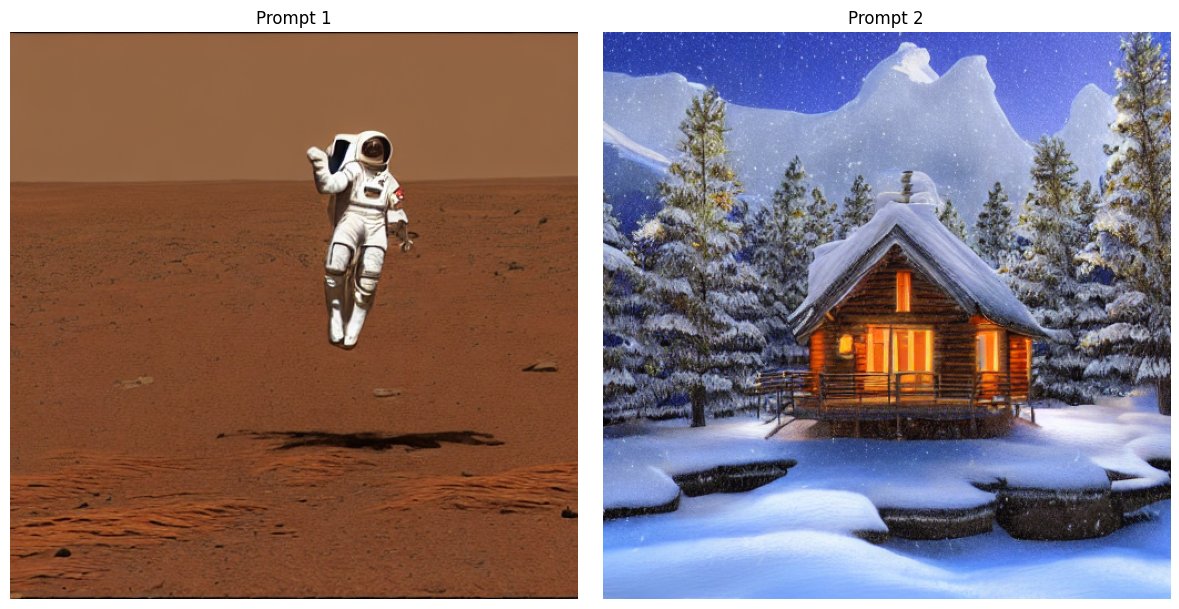

In [64]:
display_images(images)

Running inference with config-driven loader...


preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[CLIP] All keys loaded successfully ✅
[VAE] All keys loaded successfully ✅
[UNet] All keys loaded successfully ✅


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

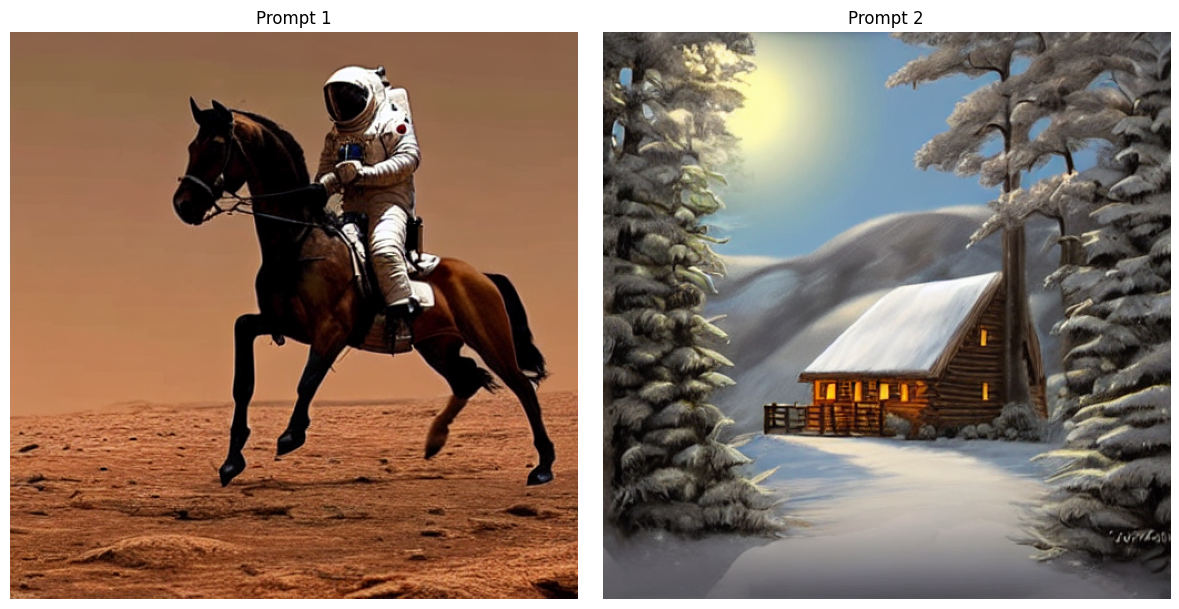

In [65]:
#  StableDiffusionLoader
from infer.infer_stable_diffusion_loader import infer_stable_diffusion_loader

print("Running inference with config-driven loader...")
images_loader = infer_stable_diffusion_loader("config.yaml", prompts)
display_images(images_loader)

In [43]:
!pytest tests/test_model.py -k test_model_weight_keys -v --capture=no

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4
plugins: langsmith-0.8.9, typeguard-4.5.2, anyio-4.13.0
collected 10 items / 9 deselected / 1 selected                                 

tests/test_model.py::test_model_weight_keys Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
UNet Missing: 0, Unexpected: 0
VAE Missing: 0, Unexpected: 0
Loading weights: 100% 196/196 [00:00<00:00, 6326.54it/s]
CLIP Missing (excl position_ids): 0, Unexpected: 0
PASSED

=============================== warnings s

In [44]:
!pytest tests/test_model.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4
plugins: langsmith-0.8.9, typeguard-4.5.2, anyio-4.13.0
collected 10 items                                                             

tests/test_model.py::test_timestep_embedding PASSED                      [ 10%]
tests/test_model.py::test_time_embedding PASSED                          [ 20%]
tests/test_model.py::test_resnet_block_2d PASSED                         [ 30%]
tests/test_model.py::test_attention PASSED                               [ 40%]
tests/test_model.py::test_transformer_2d_model PASSED                    [ 50%]
tests/test_model.py::test_clip_text_model PASSED                         [ 60%]
tests/test_model.py::test_autoencoder_kl PASSED                          [ 70%]
t

In [45]:
# !python -c "from diffusers import UNet2DConditionModel as HFUNet2DConditionModel; hfu = HFUNet2DConditionModel.from_pretrained('runwayml/stable-diffusion-v1-5', subfolder='unet'); print('config:', hfu.config); print('sample attn layers info:'); for name, module in hfu.named_modules():;     if 'attn1' in name or 'attn2' in name:;         print(name, 'heads:', getattr(module, 'heads', None), 'scale:', getattr(module, 'scale', None));         break"

In [49]:
! python test_equivalence.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
--- Time Embedding ---
Time Embedding Diff: 0.0
--- Resnet Block ---
Resnet Block Diff: 4.267692565917969e-05
--- Attention ---
Traceback (most recent call last):
  File "/content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4/test_equivalence.py", line 92, in <module>
  File "/content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4/test_equivalence.py", line 52, in check_attention
    custom.eval()
         ^^^^^^^^^
TypeError: Attention.__init__() got an unexpected keyword argument 'encoder_hidden_states_dim'
